### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load data

In [2]:
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)

# Load
df_bp  = pd.read_csv("../data/raw/business_partners.csv", low_memory=False)

# Numeric conversions
numeric_cols_bp = [
    "AmountInDisplayCurrency", "BalanceAmountInDisplayCurrency", "DebitAmountInDisplayCrcy", "CreditAmountInDisplayCrcy"
]
for col in numeric_cols_bp:
    df_bp[col] = pd.to_numeric(df_bp[col], errors="coerce")

# Date conversions
def parse_sap_date(val):
    try:
        ms = int(str(val).replace("/Date(", "").replace(")/", "").split("+")[0])
        return pd.Timestamp(ms, unit="ms")
    except:
        return pd.NaT

df_bp["CANetDueDate"] = df_bp["CANetDueDate"].apply(parse_sap_date)

# Anonymize for portfolio display
import hashlib

def anonymize_name(name):
    if pd.isna(name) or name == "":
        return "CUSTOMER_UNKNOWN"
    hash_val = hashlib.md5(str(name).encode()).hexdigest()[:6].upper()
    return f"CUSTOMER_{hash_val}"

df_bp["BusinessPartnerName"] = df_bp["BusinessPartnerName"].apply(anonymize_name)
df_bp["FirstName"]  = "REDACTED"
df_bp["LastName"]   = "REDACTED"
df_bp["PostalCode"] = "REDACTED"

# Verify
print("BusinessPartnerList:", df_bp.shape)
print("\nDate check:")
print(df_bp[["CANetDueDate"]].head(3))
print("\nKey dtypes:")
print(df_bp[["BalanceAmountInDisplayCurrency", "CANetDueDate"]].dtypes)

BusinessPartnerList: (616248, 36)

Date check:
  CANetDueDate
0   2025-04-29
1   2025-04-29
2   2025-04-29

Key dtypes:
BalanceAmountInDisplayCurrency           float64
CANetDueDate                      datetime64[ms]
dtype: object


### Drop columns

In [3]:
drop_bp = [
    "__metadata", "GeneratedId", "CAWorklistProcessingState",
    "CAWorklistProcessingStateText", "WorklistCreationDate",
    "CAGroupByKey", "Segment", "Division", "BusinessArea",
    "CAAuthorizationGroup", "CASubApplication",
    "CAStatisticalItemCode", "CAContract", "ContractAccountCategory",
    "DisplayCurrency", "CARepetitionItemNumber", "CASubItemNumber",
    "WorklistCreationTime"
]

df_bp  = df_bp.drop(columns=drop_bp, errors="ignore")

print("df_bp shape:", df_bp.shape)
print("df_bp columns:", df_bp.columns.tolist())

df_bp shape: (616248, 19)
df_bp columns: ['AmountInDisplayCurrency', 'NumberOfItems', 'BalanceAmountInDisplayCurrency', 'DebitAmountInDisplayCrcy', 'CreditAmountInDisplayCrcy', 'BusinessPartner', 'BusinessPartnerName', 'CADocumentNumber', 'CABPItemNumber', 'CompanyCode', 'LastName', 'FirstName', 'PostalCode', 'ContractAccount', 'CAAccountDeterminationCode', 'CADocumentType', 'CAMainTransaction', 'CASubTransaction', 'CANetDueDate']


### Shape, dtypes, nulls

In [4]:
print("Shape:", df_bp.shape)
print("\nDtypes:")
print(df_bp.dtypes)
print("\nNulls:")
print(df_bp.isnull().sum())

Shape: (616248, 19)

Dtypes:
AmountInDisplayCurrency                  float64
NumberOfItems                              int64
BalanceAmountInDisplayCurrency           float64
DebitAmountInDisplayCrcy                 float64
CreditAmountInDisplayCrcy                float64
BusinessPartner                            int64
BusinessPartnerName                          str
CADocumentNumber                           int64
CABPItemNumber                             int64
CompanyCode                                  str
LastName                                     str
FirstName                                    str
PostalCode                                   str
ContractAccount                            int64
CAAccountDeterminationCode                   str
CADocumentType                               str
CAMainTransaction                            str
CASubTransaction                             str
CANetDueDate                      datetime64[ms]
dtype: object

Nulls:
AmountInDisplayCur

### Descriptive statistics

In [5]:
df_bp.head()

,AmountInDisplayCurrency,NumberOfItems,BalanceAmountInDisplayCurrency,DebitAmountInDisplayCrcy,CreditAmountInDisplayCrcy,BusinessPartner,BusinessPartnerName,CADocumentNumber,CABPItemNumber,CompanyCode,LastName,FirstName,PostalCode,ContractAccount,CAAccountDeterminationCode,CADocumentType,CAMainTransaction,CASubTransaction,CANetDueDate
0,-19.95,1,-57.49,0.00,-57.49,1053268,CUSTOMER_190CEB,140393243,1,PR01,REDACTED,REDACTED,REDACTED,10047646,Z1,YL,0060,0010,2025-04-29
1,-17.44,1,-57.49,0.00,-57.49,1053268,CUSTOMER_190CEB,120392059,1,PR01,REDACTED,REDACTED,REDACTED,10047646,Z1,YL,0060,0010,2025-04-29
2,-20.10,1,-57.49,0.00,-57.49,1053268,CUSTOMER_190CEB,140393243,2,PR01,REDACTED,REDACTED,REDACTED,10047646,Z1,YL,0060,0010,2025-04-29
3,-0.01,1,-0.01,0.00,-0.01,1053269,CUSTOMER_CBAE85,150005573,1,PR01,REDACTED,REDACTED,REDACTED,10055365,Z1,YV,0060,0010,2024-04-08
4,-53.64,1,-196.49,0.00,-196.49,1053277,CUSTOMER_B956E0,130366828,2,PR01,REDACTED,REDACTED,REDACTED,10071405,Z1,YL,0060,0010,2025-04-03


In [6]:
describe_bp = [
    "AmountInDisplayCurrency",
    "BalanceAmountInDisplayCurrency",
    "DebitAmountInDisplayCrcy",
    "CreditAmountInDisplayCrcy"
]

display(df_bp[describe_bp].describe())

,AmountInDisplayCurrency,BalanceAmountInDisplayCurrency,DebitAmountInDisplayCrcy,CreditAmountInDisplayCrcy
count,"616,248.00","616,248.00","616,248.00","616,248.00"
mean,-257.58,"952,898.50","1,224,618.73","-271,720.23"
std,"50,518.87","2,268,171.48","1,503,560.20","1,861,701.99"
min,"-15,732,175.45","-39,370,112.42",0.00,"-51,829,101.38"
25%,-8.68,"4,479.82","32,221.92","-110,650.58"
50%,-2.07,"190,058.71","279,737.68","-28,070.99"
75%,-0.01,"3,171,842.37","3,199,913.36","-6,942.09"
max,-0.01,"42,281,599.56","42,281,625.06",-0.01


### Credit amount distribution

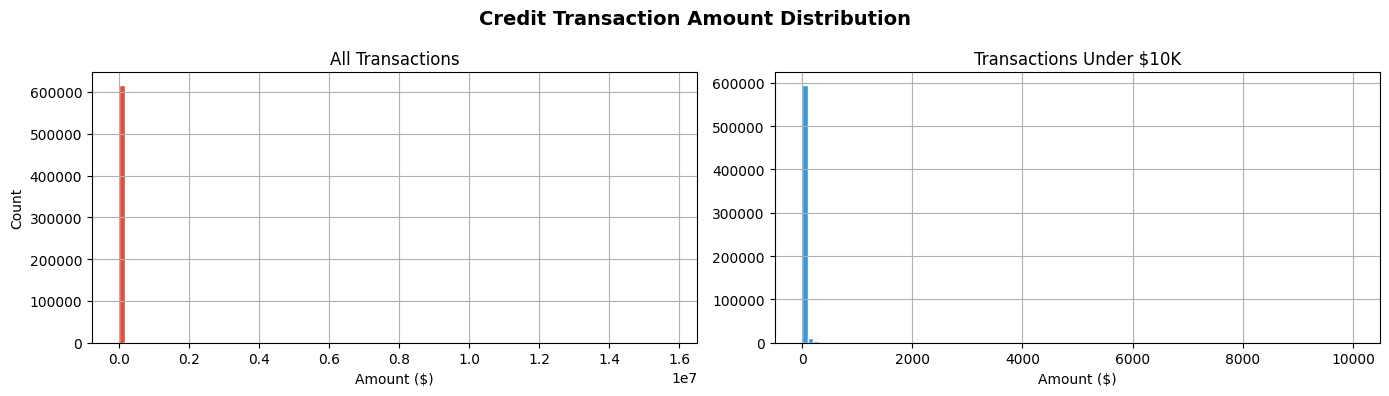

Largest transaction: $ 15732175.45
Median transaction:  $ 2.07
Over $10K:            353
Over $100K:           36


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_bp["AmountInDisplayCurrency"].abs().hist(
    bins=100, ax=axes[0], color="#e74c3c", edgecolor="white"
)
axes[0].set_title("All Transactions")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")

df_bp[df_bp["AmountInDisplayCurrency"].abs() < 10000]["AmountInDisplayCurrency"].abs().hist(
    bins=100, ax=axes[1], color="#3498db", edgecolor="white"
)
axes[1].set_title("Transactions Under $10K")
axes[1].set_xlabel("Amount ($)")

plt.suptitle("Credit Transaction Amount Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Largest transaction: $", round(df_bp["AmountInDisplayCurrency"].abs().max(), 2))
print("Median transaction:  $", round(df_bp["AmountInDisplayCurrency"].abs().median(), 2))
print("Over $10K:           ", (df_bp["AmountInDisplayCurrency"].abs() > 10000).sum())
print("Over $100K:          ", (df_bp["AmountInDisplayCurrency"].abs() > 100000).sum())

### Top business partners

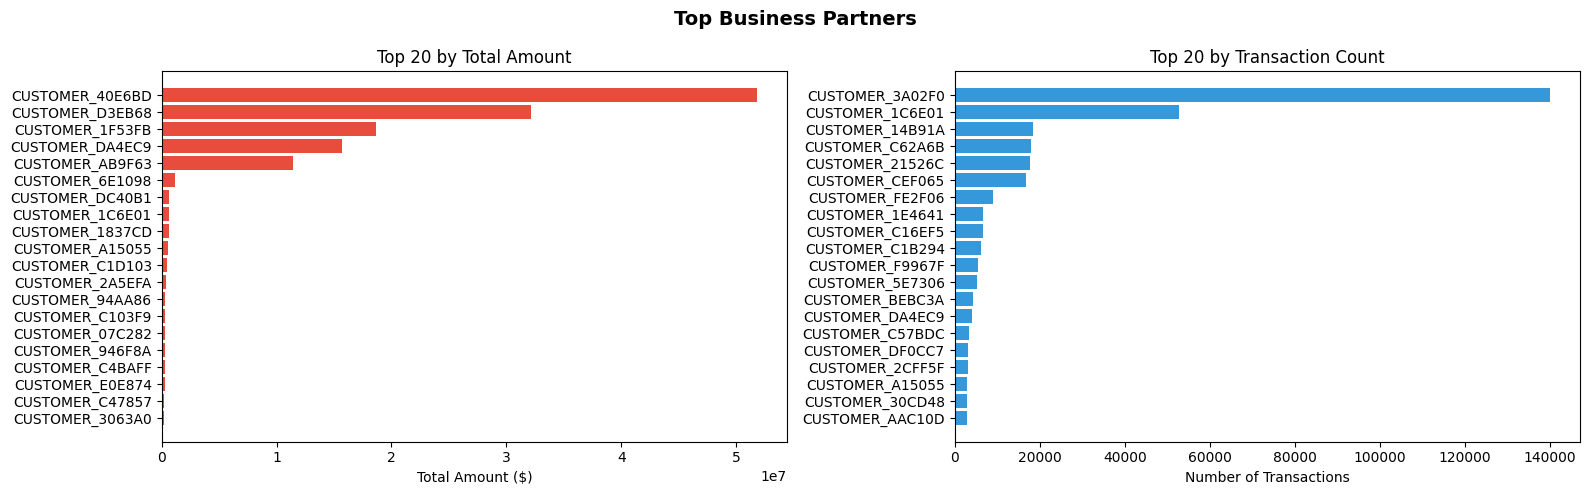

In [8]:
bp_names = df_bp[["BusinessPartner", "BusinessPartnerName"]].drop_duplicates()

top_bp = (
    df_bp.groupby("BusinessPartner")
    .agg(
        transaction_count=("AmountInDisplayCurrency", "count"),
        total_amount=("AmountInDisplayCurrency", lambda x: x.abs().sum())
    )
    .reset_index()
    .merge(bp_names, on="BusinessPartner", how="left")
    .sort_values("total_amount", ascending=False)
    .head(20)
)
top_bp["Label"] = top_bp["BusinessPartnerName"].fillna("CUSTOMER_UNKNOWN")

top_bp_count = (
    df_bp.groupby("BusinessPartner")
    .size()
    .reset_index(name="count")
    .merge(bp_names, on="BusinessPartner", how="left")
    .sort_values("count", ascending=False)
    .head(20)
)
top_bp_count["Label"] = top_bp_count["BusinessPartnerName"].fillna("CUSTOMER_UNKNOWN")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top_bp["Label"], top_bp["total_amount"], color="#e74c3c")
axes[0].set_title("Top 20 by Total Amount")
axes[0].set_xlabel("Total Amount ($)")
axes[0].invert_yaxis()

axes[1].barh(top_bp_count["Label"], top_bp_count["count"], color="#3498db")
axes[1].set_title("Top 20 by Transaction Count")
axes[1].set_xlabel("Number of Transactions")
axes[1].invert_yaxis()

plt.suptitle("Top Business Partners", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Document type breakdown

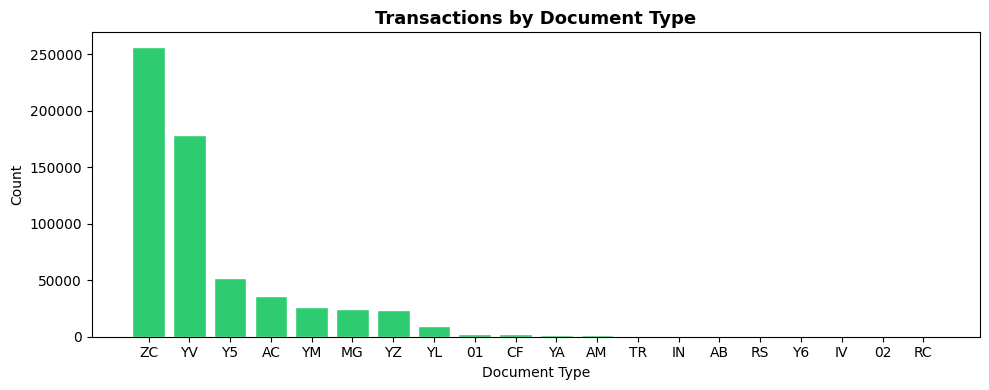

DocumentType  Count
          ZC 256375
          YV 178211
          Y5  52112
          AC  35633
          YM  25950
          MG  24709
          YZ  23232
          YL   9394
          01   2543
          CF   2375
          YA   1833
          AM   1521
          TR    649
          IN    632
          AB    569
          RS    375
          Y6     74
          IV     27
          02     20
          RC     14


In [9]:
doc_counts = df_bp["CADocumentType"].value_counts().reset_index()
doc_counts.columns = ["DocumentType", "Count"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(doc_counts["DocumentType"], doc_counts["Count"], color="#2ecc71", edgecolor="white")
ax.set_title("Transactions by Document Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Document Type")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(doc_counts.to_string(index=False))

### Transactions over time

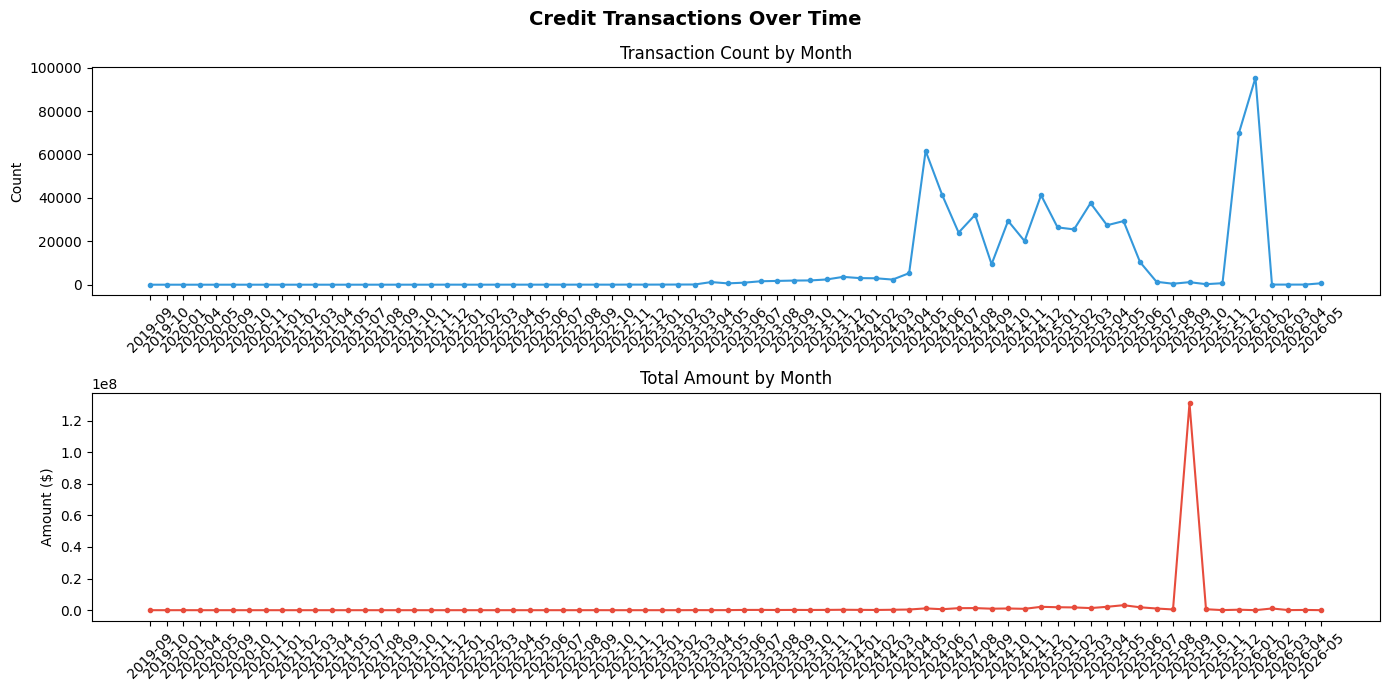

In [10]:
monthly = (
    df_bp.groupby(df_bp["CANetDueDate"].dt.to_period("M"))
    .agg(
        transaction_count=("AmountInDisplayCurrency", "count"),
        total_amount=("AmountInDisplayCurrency", lambda x: x.abs().sum())
    )
    .reset_index()
    .sort_values("CANetDueDate")
)
monthly["CANetDueDate"] = monthly["CANetDueDate"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(monthly["CANetDueDate"], monthly["transaction_count"],
             color="#3498db", marker="o", markersize=3)
axes[0].set_title("Transaction Count by Month")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(monthly["CANetDueDate"], monthly["total_amount"],
             color="#e74c3c", marker="o", markersize=3)
axes[1].set_title("Total Amount by Month")
axes[1].set_ylabel("Amount ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Credit Transactions Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Balance distribution

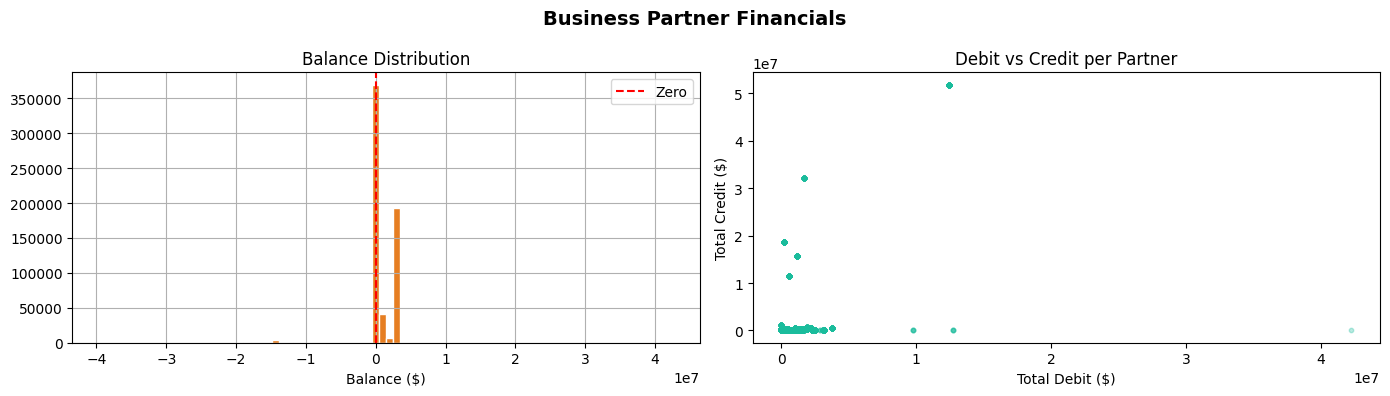

Negative balance (owe money): 109755
Positive balance (in credit):  506259
Largest debit:  $ 42281625.06
Largest credit: $ 51829101.38


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_bp["BalanceAmountInDisplayCurrency"].hist(
    bins=80, ax=axes[0], color="#e67e22", edgecolor="white"
)
axes[0].set_title("Balance Distribution")
axes[0].set_xlabel("Balance ($)")
axes[0].axvline(0, color="red", linestyle="--", label="Zero")
axes[0].legend()

axes[1].scatter(
    df_bp["DebitAmountInDisplayCrcy"],
    df_bp["CreditAmountInDisplayCrcy"].abs(),
    alpha=0.3, color="#1abc9c", s=10
)
axes[1].set_title("Debit vs Credit per Partner")
axes[1].set_xlabel("Total Debit ($)")
axes[1].set_ylabel("Total Credit ($)")

plt.suptitle("Business Partner Financials", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Negative balance (owe money):", (df_bp["BalanceAmountInDisplayCurrency"] < 0).sum())
print("Positive balance (in credit): ", (df_bp["BalanceAmountInDisplayCurrency"] > 0).sum())
print("Largest debit:  $", round(df_bp["DebitAmountInDisplayCrcy"].max(), 2))
print("Largest credit: $", round(df_bp["CreditAmountInDisplayCrcy"].abs().max(), 2))

### Early anomaly signals

In [12]:
print("=" * 50)
print("EARLY ANOMALY SIGNALS")
print("=" * 50)

# Extreme amounts
threshold = df_bp["AmountInDisplayCurrency"].abs().quantile(0.99)
extreme   = df_bp[df_bp["AmountInDisplayCurrency"].abs() > threshold]
print("\nTransactions above 99th percentile ($", round(threshold, 2), "):", len(extreme))
print(extreme[["BusinessPartner", "ContractAccount",
               "CADocumentType", "CAMainTransaction",
               "AmountInDisplayCurrency"]].head(10).to_string(index=False))

# High volume partners
bp_names = df_bp[["BusinessPartner", "BusinessPartnerName"]].drop_duplicates()
trans_counts = (
    df_bp["BusinessPartner"].value_counts()
    .reset_index()
    .rename(columns={"count": "TransactionCount"})
    .merge(bp_names, on="BusinessPartner", how="left")
)
high_volume = trans_counts[trans_counts["TransactionCount"] > trans_counts["TransactionCount"].quantile(0.99)]
print("\nTop 1% highest volume partners:")
print(high_volume.head(10).to_string(index=False))

# Extreme balances - deduplicated
extreme_bal = (
    df_bp.groupby(["BusinessPartner", "BusinessPartnerName"])
    .agg(
        balance=("BalanceAmountInDisplayCurrency", "max"),
        total_debit=("DebitAmountInDisplayCrcy", "sum")
    )
    .reset_index()
)
extreme_bal = extreme_bal[extreme_bal["balance"].abs() > 100000].sort_values("balance", ascending=False)
print("\nPartners with balance over $100K (deduplicated):", len(extreme_bal))
print(extreme_bal.head(10).to_string(index=False))

EARLY ANOMALY SIGNALS

Transactions above 99th percentile ($ 451.37 ): 6163
 BusinessPartner  ContractAccount CADocumentType CAMainTransaction  AmountInDisplayCurrency
         1053624         10185587             TR              0060                  -610.70
         1053624         10185587             YZ              0600                  -905.41
         1053624         10185587             YZ              0060                -4,102.04
         1053624         10185587             YZ              0060                -1,454.22
         1053645         10073081             MG              MG00                  -482.47
         1053670         10219005             YZ              0600                  -839.17
         1053670         10219005             YZ              0600                  -739.53
         1053670         10219005             YZ              0600                -1,409.70
         1053670         10219005             YZ              0600                  -555.05
    

### Key findings

In [13]:
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 55)

top_balance = (
    df_bp.groupby("BusinessPartner")["BalanceAmountInDisplayCurrency"]
    .max().sort_values(ascending=False)
)
top_debit = (
    df_bp.groupby("BusinessPartner")["DebitAmountInDisplayCrcy"]
    .max()
    .sort_values(ascending=False)
)

print("""
DATASET
-------
Total transactions:          {:,}
Unique business partners:    {:,}
Date range:                  {} to {}

AMOUNT SIGNALS
--------------
Largest single transaction:  ${:,.2f}
Median transaction:          ${:,.2f}
Transactions over $10K:      {:,}
Transactions over $100K:     {:,}
99th percentile threshold:   ${:,.2f}
Transactions above it:       {:,}

HIGH VOLUME PARTNERS
--------------------
Top 1% partners account for {:,} partners

HIGH BALANCE PARTNERS
---------------------
Partners with balance over $100K:  {:,}
Highest balance:  BP {}  ${:,.2f}
Highest debit:    BP {}  ${:,.2f}

NEXT STEP → 02_features_and_model.ipynb
""".format(
    len(df_bp),
    df_bp["BusinessPartner"].nunique(),
    df_bp["CANetDueDate"].min(),
    df_bp["CANetDueDate"].max(),
    df_bp["AmountInDisplayCurrency"].abs().max(),
    df_bp["AmountInDisplayCurrency"].abs().median(),
    (df_bp["AmountInDisplayCurrency"].abs() > 10000).sum(),
    (df_bp["AmountInDisplayCurrency"].abs() > 100000).sum(),
    df_bp["AmountInDisplayCurrency"].abs().quantile(0.99),
    (df_bp["AmountInDisplayCurrency"].abs() > df_bp["AmountInDisplayCurrency"].abs().quantile(0.99)).sum(),
    (df_bp["BusinessPartner"].value_counts() > df_bp["BusinessPartner"].value_counts().quantile(0.99)).sum(),
    (df_bp.groupby("BusinessPartner")["BalanceAmountInDisplayCurrency"].max().abs() > 100000).sum(),
    top_balance.index[0], top_balance.iloc[0],
    top_debit.index[0], top_debit.iloc[0]
))

EDA SUMMARY — KEY FINDINGS

DATASET
-------
Total transactions:          616,248
Unique business partners:    20,605
Date range:                  2019-09-27 00:00:00 to 2026-05-19 00:00:00

AMOUNT SIGNALS
--------------
Largest single transaction:  $15,732,175.45
Median transaction:          $2.07
Transactions over $10K:      353
Transactions over $100K:     36
99th percentile threshold:   $451.37
Transactions above it:       6,163

HIGH VOLUME PARTNERS
--------------------
Top 1% partners account for 207 partners

HIGH BALANCE PARTNERS
---------------------
Partners with balance over $100K:  386
Highest balance:  BP 1000225  $42,281,599.56
Highest debit:    BP 1000225  $42,281,625.06

NEXT STEP → 02_features_and_model.ipynb

